## Linear Regression 

In [4]:

%pip install pandas numpy matplotlib seaborn scikit-learn
# import libraries

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# load the dataset
df= pd.read_csv("C:\\Users\\guntu\\OneDrive\\Desktop\\Machine Learning- Linear regression\\Linear Regression\\linear_regression_datasest.csv")
df

,Feature_1,Feature_2,Target
0,18.727006,26.661964,75.032045
1,47.535715,58.771085,186.095787
2,36.599697,88.565125,200.512604
3,29.932924,75.900240,174.586253
4,7.800932,82.590503,132.746780
...,...,...,...
995,4.579104,69.125964,93.751176
996,45.865679,96.095316,245.192409
997,6.840932,16.206221,62.434222
998,47.511868,15.134925,126.081746


In [7]:
# data preprocessing
df.isnull().sum()

Feature_1    0
Feature_2    0
Target       0
dtype: int64

In [8]:
df.duplicated().any()

np.False_

In [9]:
df.columns

Index(['Feature_1', 'Feature_2', 'Target'], dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  1000 non-null   float64
 1   Feature_2  1000 non-null   float64
 2   Target     1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [11]:
df.dtypes

Feature_1    float64
Feature_2    float64
Target       float64
dtype: object

In [12]:
df.shape

(1000, 3)

In [13]:
df.head()

,Feature_1,Feature_2,Target
0,18.727006,26.661964,75.032045
1,47.535715,58.771085,186.095787
2,36.599697,88.565125,200.512604
3,29.932924,75.900240,174.586253
4,7.800932,82.590503,132.746780


In [14]:
df.describe

<bound method NDFrame.describe of      Feature_1  Feature_2      Target
0    18.727006  26.661964   75.032045
1    47.535715  58.771085  186.095787
2    36.599697  88.565125  200.512604
3    29.932924  75.900240  174.586253
4     7.800932  82.590503  132.746780
..         ...        ...         ...
995   4.579104  69.125964   93.751176
996  45.865679  96.095316  245.192409
997   6.840932  16.206221   62.434222
998  47.511868  15.134925  126.081746
999  22.300289  35.396837   84.427682

[1000 rows x 3 columns]>

In [15]:
# check the corelation btw two variables
df.corr

<bound method DataFrame.corr of      Feature_1  Feature_2      Target
0    18.727006  26.661964   75.032045
1    47.535715  58.771085  186.095787
2    36.599697  88.565125  200.512604
3    29.932924  75.900240  174.586253
4     7.800932  82.590503  132.746780
..         ...        ...         ...
995   4.579104  69.125964   93.751176
996  45.865679  96.095316  245.192409
997   6.840932  16.206221   62.434222
998  47.511868  15.134925  126.081746
999  22.300289  35.396837   84.427682

[1000 rows x 3 columns]>

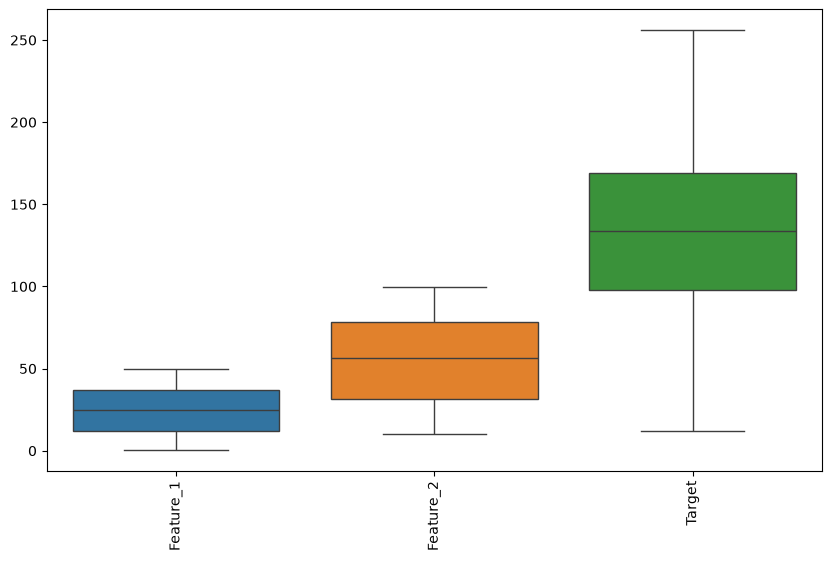

In [17]:
# EDA (Exploratory Data Analysis)
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()


In [18]:
# dividing the data into the features and target values
x=df.drop('Target', axis=1)
y=df['Target']

In [19]:
# split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [20]:
# import model
from sklearn.linear_model import LinearRegression
# create the instance of model
model=LinearRegression()
# train the model
model.fit(x_train,y_train)
# predict the x_test data
y_pred=model.predict(x_test)

In [21]:
# check the loss
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# find the MAE
MAE=mean_absolute_error(y_test,y_pred)
# find the MSE
MSE=mean_squared_error(y_test,y_pred)
# find the R2 score
R2=r2_score(y_test,y_pred)
# print the MSE and R2 score
print("Mean Squared Error:", MSE)
print("Mean Absolute Error:", MAE)
print("R2 Score:", R2)


Mean Squared Error: 100.35222719050995
Mean Absolute Error: 7.933952565095109
R2 Score: 0.957500280399683


In [ ]:
# get the intercept and coefficients of the model
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 4.831195723111648
Coefficients: [2.50912402 1.19752671]


In [23]:
# create a dataframe to compare the actual and predicted values
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
521,167.503605,165.302671
737,154.317860,140.229835
740,165.062247,164.042397
660,135.199609,126.211503
411,154.297221,148.060034
678,150.078154,157.134562
626,116.753740,96.490422
513,121.399519,127.424609
859,119.269892,103.564853
136,176.612053,173.632834


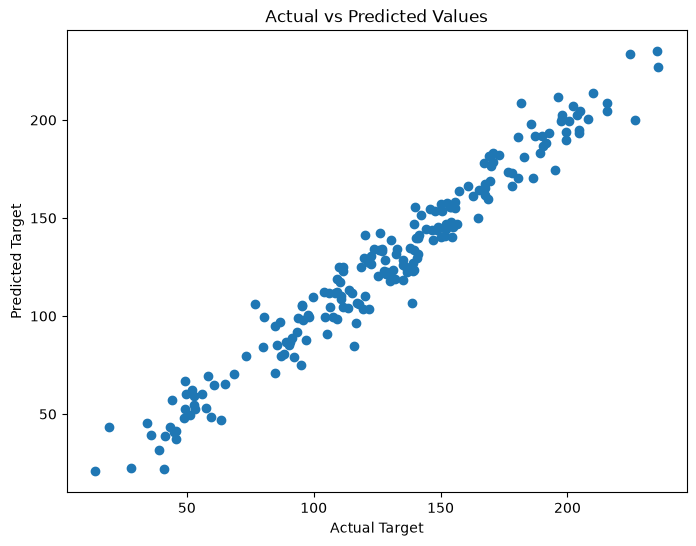

In [24]:
# actual vs predicted values plot
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted Values")

plt.show()

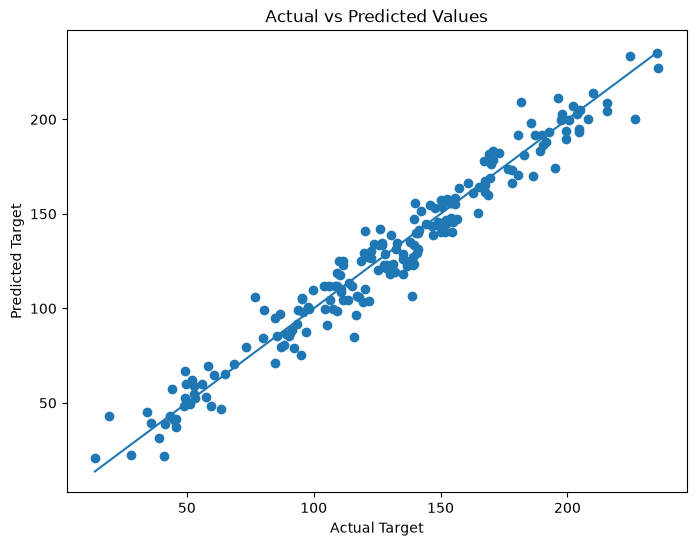

In [ ]:
# actual vs predicted values  scatter plot
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted Values")

plt.show()

In [ ]:
# residual plot
residuals = y_test - y_pred

print(residuals.head(10))

521     2.200934
737    14.088025
740     1.019851
660     8.988106
411     6.237187
678    -7.056408
626    20.263318
513    -6.025090
859    15.705040
136     2.979219
Name: Target, dtype: float64


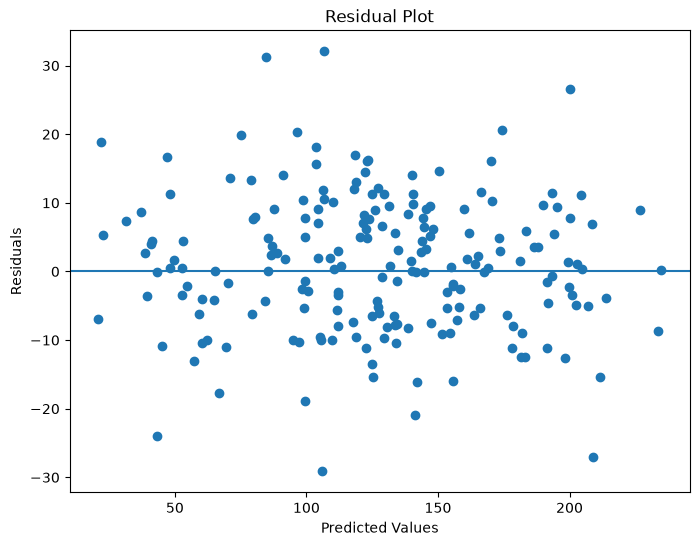

In [ ]:
# residual plot
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()